In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

def rssq(a, axis=0):
    """Compute the root sum of squares of the input array."""
    return np.sqrt(np.sum(np.abs(a*a.conj()), axis=axis))

def load_sensmap(filename: str = 'sensmaps.h5') -> np.ndarray:
    """Load sensitivity map from an HDF5 file."""
    with h5py.File(filename, 'r') as f:
        m = f['maps']['magnitude']
        p = f['maps']['phase']
        n_ch = len(m)
        mag = [m[f"{i:02d}"][:] for i in range(n_ch)]
        pha = [p[f"{i:02d}"][:] for i in range(n_ch)]

    return np.asarray(mag, dtype=np.float32) * np.exp(1j * np.asanyarray(pha, dtype=np.float32))


In [2]:
sens = load_sensmap()

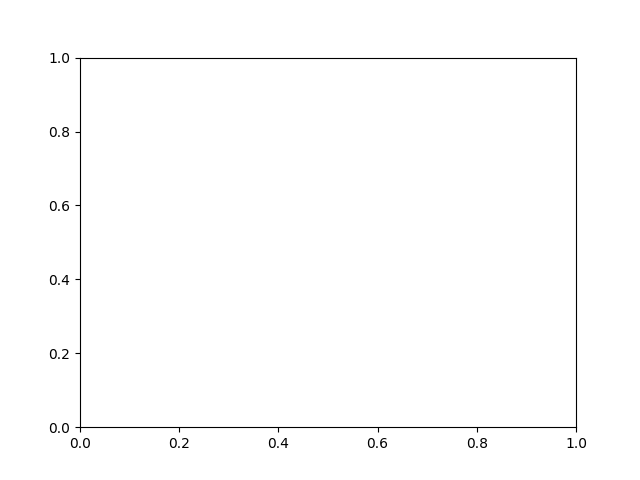

In [18]:
ndv(np.abs(sens))

In [4]:
# importing element tree
# under the alias of ET
import xml.etree.ElementTree as ET

# Passing the path of the
# xml document to enable the
# parsing process
tree = ET.parse('Body6Spine18.xml')

# getting the parent tag of
# the xml document
coils_xml = tree.findall('BIOTSAVARTLOOP')


In [5]:
coils_xml[0].attrib

{'Azimuth': '45',
 'Dim': '3',
 'Extent': '500',
 'Name': 'B11',
 'Points': '64',
 'Polar': '90',
 'Radius': '80',
 'XPos': '144',
 'YPos': '130',
 'ZPos': '0'}

In [15]:
from ndview import ndv
def circle3d(radius, n_points=100) -> np.ndarray:
    """Generate a 3D circle at a given position with a specified radius."""
    theta = np.linspace(0, 2 * np.pi, n_points)
    y = radius * np.cos(theta)
    z = radius * np.sin(theta)
    x = np.zeros_like(y)
    return np.array([x, y, z]).T

def rotate_circle(circle: np.ndarray, azimuth: float, polar: float) -> np.ndarray:
    """Rotate a circle in 3D space based on azimuth and polar angles."""
    azimuth_rad = np.radians(azimuth)
    polar_rad = np.radians(polar)
    
    # Rotation matrices
    R_azimuth = np.array([[np.cos(azimuth_rad), -np.sin(azimuth_rad), 0],
                          [np.sin(azimuth_rad), np.cos(azimuth_rad), 0],
                          [0, 0, 1]])
    
    R_polar = np.array([[1, 0, 0],
                        [0, np.cos(polar_rad), -np.sin(polar_rad)],
                        [0, np.sin(polar_rad), np.cos(polar_rad)]])
    
    return circle @ (R_azimuth @ R_polar).T
    
def plot_quadrants(ax, array, fixed_coord, cmap, extent:float =64):
    """For a given 3d *array* plot a plane with *fixed_coord*, using four quadrants."""
    nx, ny, nz = array.shape
    index = {
        'x': (nx // 2, slice(None), slice(None)),
        'y': (slice(None), ny // 2, slice(None)),
        'z': (slice(None), slice(None), nz // 2),
    }[fixed_coord]
    plane_data = array[index]

    n0, n1 = plane_data.shape
    quadrants = [
        plane_data[:n0 // 2, :n1 // 2],
        plane_data[:n0 // 2, n1 // 2:],
        plane_data[n0 // 2:, :n1 // 2],
        plane_data[n0 // 2:, n1 // 2:]
    ]

    min_val = array.min()
    max_val = array.max()

    cmap = plt.get_cmap(cmap)

    for i, quadrant in enumerate(quadrants):
        facecolors = cmap((quadrant - min_val) / (max_val - min_val))
        if fixed_coord == 'x':
            Y, Z = extent*(np.mgrid[0:ny // 2, 0:nz // 2]-ny/2)/ny
            X = (extent / 2) * np.zeros_like(Y)
            Y_offset = (i // 2) * extent / 2
            Z_offset = (i % 2) * extent / 2
            ax.plot_surface(X, Y + Y_offset, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False)
        elif fixed_coord == 'y':
            X, Z = extent*(np.mgrid[0:nx // 2, 0:nz // 2] - nx/2)/nx
            Y = (extent / 2) * np.zeros_like(X)
            X_offset = (i // 2) * extent / 2
            Z_offset = (i % 2) * extent / 2
            ax.plot_surface(X + X_offset, Y, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False)
        elif fixed_coord == 'z':
            X, Y = extent*(np.mgrid[0:nx // 2, 0:ny // 2] - nx/2)/nx
            Z = (extent / 2) * np.zeros_like(X)
            X_offset = (i // 2) * extent / 2
            Y_offset = (i % 2) * extent / 2
            ax.plot_surface(X + X_offset, Y + Y_offset, Z, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False)


def figure_3D_array_slices(array, ax, cmap=None, extent:float =64):
    """Plot a 3d array using three intersecting centered planes."""

    ax.set_box_aspect(array.shape)
    plot_quadrants(ax, array, 'x', cmap=cmap, extent=extent)
    plot_quadrants(ax, array, 'y', cmap=cmap, extent=extent)
    plot_quadrants(ax, array, 'z', cmap=cmap, extent=extent)


class Coil:
    def __init__(self, coil_element, sensmap):
        self.name = coil_element.attrib['Name']
        self.position = np.array([float(coil_element.attrib['XPos']),
                                  float(coil_element.attrib['YPos']),
                                  float(coil_element.attrib['ZPos'])])
        self.radius = float(coil_element.attrib['Radius'])
        self.azimuth = float(coil_element.attrib['Azimuth'])
        self.polar = float(coil_element.attrib['Polar'])
        self.extent = float(coil_element.attrib['Extent'])
        self.sensmap = sensmap
    
    def __repr__(self):
        return f"Coil(position={self.position}, radius={self.radius}, azimuth={self.azimuth}, polar={self.polar})"
    
    def show(self, show_sensmap: bool = True, ax=None, callshow: bool = True):
        """Visualize the coil in 3D."""

        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
        if show_sensmap:
            figure_3D_array_slices(np.abs(self.sensmap.transpose(2, 1, 0)), ax, cmap='turbo', extent=self.extent)
        
        ax.text(*self.position, self.name, fontsize=12, color='red')
        circ = circle3d(self.radius, n_points=201)
        circ = rotate_circle(circ, self.azimuth, self.polar)
        circ += self.position
        ax.plot(circ[:, 0], circ[:, 1], circ[:, 2], color='blue', linewidth=2)
        X, Y, Z = np.meshgrid(np.linspace(-self.extent/2, self.extent/2, 64),
                             np.linspace(-self.extent/2, self.extent/2, 64),
                             np.linspace(-self.extent/2, self.extent/2, 64))
        X = X.flatten()
        Y = Y.flatten()
        Z = Z.flatten()

        
        ax.set_title('Coil Position')
        ax.set_xlabel('X Position [mm]')
        ax.set_ylabel('Y Position [mm]')
        ax.set_zlabel('Z Position [mm]')
        # ax.set_xlim([-self.extent/2, self.extent/2])
        # ax.set_ylim([-self.extent/2, self.extent/2])
        # ax.set_zlim([-self.extent/2, self.extent/2])
        if callshow:
            plt.show()
    
    def show_sensmap(self):
        """Visualize the sensitivity map of the coil."""
        ndv(np.abs(self.sensmap))

class CoilArray(dict):
    def __init__(self, coils: list[Coil] = []):
        super().__init__()
        for coil in coils:
            if not isinstance(coil, Coil):
                raise TypeError(f"Expected Coil instance, got {type(coil)}")
            self[coil.name] = coil

        self.extent = coils[0].extent if coils else 0.0
    
    def load_from_xml(self, xml_file: str, sensmap: np.ndarray):
        """Load coils from an XML file and associate them with a sensitivity map."""
        tree = ET.parse(xml_file)
        coils_xml = tree.findall('BIOTSAVARTLOOP')
        for ci, coil_element in enumerate(coils_xml):
            coil = Coil(coil_element, sensmap[ci, :, :, :])
            self[coil.name] = coil
        
        self.extent = float(coils_xml[0].attrib['Extent'])

    def show(self, show_sensmap: bool = True):
        """Visualize all coils in the array."""

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        for coil in self.values():
            coil.show(ax=ax, show_sensmap=False, callshow=False)

        if show_sensmap:
            sensmap_rssq = rssq(np.abs([c.sensmap for c in self.values()]), axis=0).transpose(2, 1, 0)
            figure_3D_array_slices(sensmap_rssq, ax, cmap='turbo', extent=self.extent)

        plt.show()



In [16]:
coils = CoilArray()
coils.load_from_xml('Body6Spine18.xml', sens)


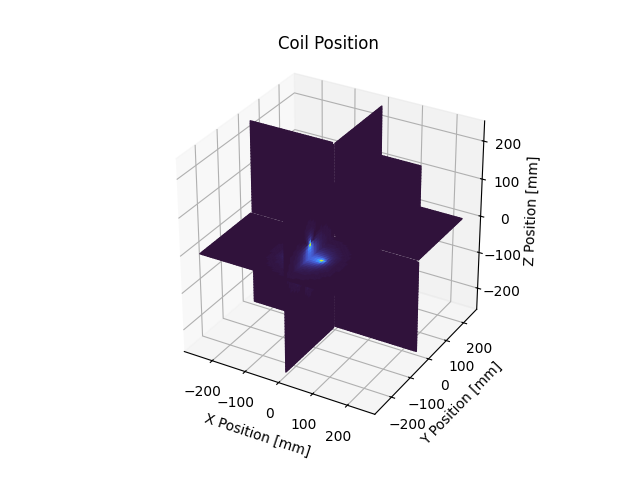

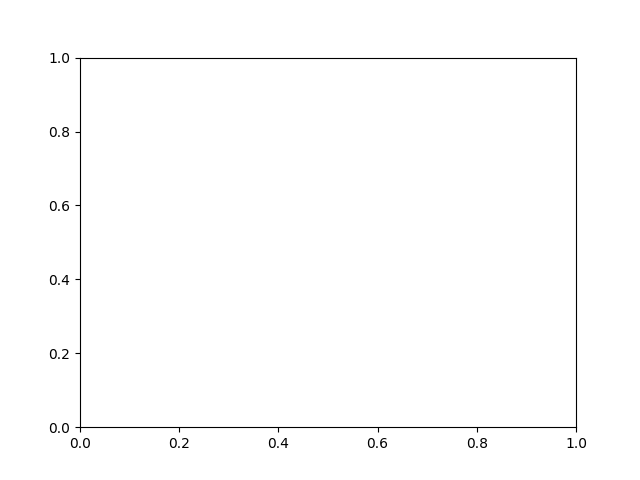

In [17]:
coils['S1S'].show(show_sensmap=True)
coils['S1S'].show_sensmap()

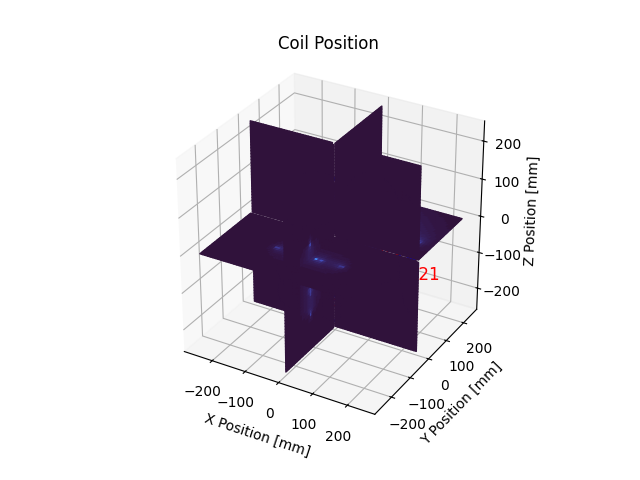

In [10]:
coils.show(show_sensmap=True)